# 😵‍💫 Basics of Chatting with a LLM (Template for Sentiment Classification with Instructions)

🔹 Understanding System, User, and Assistant Roles in Chat Templates

Language models use structured **chat formats** to distinguish between different roles in a conversation.  
**During fine-tuning of the base models they are explicitly trained to follow these formats**, ensuring they can properly interpret instructions, user inputs, and their own responses.
Most chat-based LLMs recognize these **three primary roles**:

- **`system`** → Provides **instructions** on how the assistant should behave.  
- **`user`** → Represents **human input** (questions, commands, or prompts).  
- **`assistant`** → The model's **response** based on the system prompt & user input.  

⚠️ **The correct format depends on the model's fine-tuning!**  
Different models **interpret and format these roles differently**, depending on their fine-tuning.
To prevent formatting errors, **use `apply_chat_template`**, which automatically formats chat input according to the model's expected structure and indicates possible formating errors (e.g., whether the **`system`** role is supported).

---

In [ ]:
!pip install -q -U torch==2.6.0+cu124
!pip install -q -U transformers==4.49.0
!pip install -q -U bitsandbytes==0.45.3
!pip install -q -U datasets==3.4.0
!pip install -q -U peft==0.14.0
!pip install -q -U accelerate==1.5.2
!pip install -q -U trl==0.15.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import gc
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from transformers import set_seed
from sklearn.metrics import classification_report
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline

SEED = 123456789
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

# As in the QLoRa paper
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
    use_cache=False
)

tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [ ]:
task = ("You’re a binary classification model for sentiment analysis.\n"
        "Classify the sentiment of the input as positive or negative.\n\n"
        "Expected Output:\n"
        "  - POS for positive sentiment\n"
        "  - NEG for negative sentiment\n\n"
        "Only return one of the two labels POS or NEG, nothing more and nothing less!")

In [ ]:
def generate_input(system=None, user=None, assistant=None):
    return [
        message for message in [
            {"role": "system", "content": system} if system else None,
            {"role": "user", "content": user} if user else None,
            {"role": "assistant", "content": assistant} if assistant else None
        ] if message
    ]

In [ ]:
def generate_answers(llm_model, llm_tokenizer, inputs, batch_size=2):
    llm_model.gradient_checkpointing_disable()
    llm_model.eval()

    chat_pipeline = pipeline(
        task="text-generation",
        model=llm_model,
        tokenizer=llm_tokenizer
    )

    formatted_inputs = [
        llm_tokenizer.apply_chat_template(
            input_text,
            tokenize=False,
            add_generation_prompt=False
        )
        for input_text in inputs
    ]

    num_batches = int(np.ceil(len(formatted_inputs) / batch_size))
    all_responses = []

    for batch in tqdm(np.array_split(formatted_inputs, num_batches)):
        batch = batch.tolist()
        responses = chat_pipeline(
            batch,
            max_new_tokens=5,
            return_full_text=False,
            # As in the LoRa paper
            num_beams=10,
            length_penalty=0.8,
            no_repeat_ngram_size=4
        )
        all_responses.extend(
            resp[0]["generated_text"].replace("assistant", "").strip() for resp in responses
        )

    return all_responses

In [ ]:
label_map = {1:"POS", 0:"NEG"}
dataset = load_dataset("stanfordnlp/sst2", split="train")
dataset = dataset.select(range(1000))

dataset = dataset.map(
    lambda x: {
        "formated_chat": tokenizer.apply_chat_template(
            generate_input(system=task,
                           user=x["sentence"],
                           assistant=label_map[x["label"]]),
            tokenize=False,
            add_generation_prompt=False
        )
    }
)

dataset = dataset.map(
    lambda x:  {"tokens_length": len(tokenizer.tokenize(x["formated_chat"]))}
)

dataset = dataset.map(lambda x: tokenizer(
    x["formated_chat"],
    max_length=128,
    truncation=True,
    padding="max_length"
), batched=True)

print("------ Dataset ------")
print(f"Length: min.: {np.min(dataset['tokens_length'])}, max.: {np.max(dataset['tokens_length'])}, mean.: {np.mean(dataset['tokens_length']):.0f}")
print(dataset)
print(tokenizer.decode(dataset[0]["input_ids"]))

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

------ Dataset ------
Length: min.: 74, max.: 127, mean.: 84
Dataset({
    features: ['idx', 'sentence', 'label', 'formated_chat', 'tokens_length', 'input_ids', 'attention_mask'],
    num_rows: 1000
})
<|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

You’re a binary classification model for sentiment analysis.
Classify the sentiment of the input as positive or negative.

Expected Output:
  - POS for positive sentiment
  - NEG for negative sentiment

Only return one of the two labels POS or NEG, nothing more and nothing less!<|eot_id|><|start_header_id|>user<|end_header_id|>

hide new secretions from the parental units<|eot_id|><|start_header_id|>assistant<|end_header_id|>

NEG<|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_

In [ ]:
train_dataset = dataset.select(range(0, 750))
eval_dataset = dataset.select(range(750, 1000))

print(train_dataset)
print(eval_dataset)

Dataset({
    features: ['idx', 'sentence', 'label', 'formated_chat', 'tokens_length', 'input_ids', 'attention_mask'],
    num_rows: 750
})
Dataset({
    features: ['idx', 'sentence', 'label', 'formated_chat', 'tokens_length', 'input_ids', 'attention_mask'],
    num_rows: 250
})


In [ ]:
eval_inputs = [generate_input(system=task, user=msg) for msg in eval_dataset["sentence"]]
y_before = generate_answers(model, tokenizer, eval_inputs, batch_size=25)

Device set to use cuda:0


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
print(Counter(y_before))
y_before = [1 if y == "POS" else 0 for y in y_before]
print(Counter(y_before))

Counter({'POS': 137, 'NEG': 110, '': 3})
Counter({1: 137, 0: 113})


In [ ]:
print(classification_report(eval_dataset["label"], y_before))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       107
           1       0.91      0.87      0.89       143

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.87      0.87      0.87       250



In [ ]:
# Parameters as in the LoRa Paper
lora_config = LoraConfig(
    r=4,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM",
)

peft_model = prepare_model_for_kbit_training(model)
peft_model = get_peft_model(model, lora_config)
peft_model.train()
peft_model.gradient_checkpointing_enable()
print(peft_model.print_trainable_parameters())

trainer = SFTTrainer(
    model=peft_model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(
        max_steps=-1,
        logging_strategy="epoch",
        eval_strategy="epoch",
        fp16=True,
        output_dir="./logs",
        optim="adamw_torch",
        report_to="none",
        per_device_train_batch_size=8,
        num_train_epochs=5,
        learning_rate=2e-4,
        lr_scheduler_type="linear",
        warmup_steps=500,
        weight_decay=0.01,
        seed=SEED
    ),
    peft_config=lora_config
)

gc.collect()
torch.cuda.empty_cache()

trainer.train()

trainable params: 1,703,936 || all params: 8,031,965,184 || trainable%: 0.0212
None


Converting train dataset to ChatML:   0%|          | 0/750 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/750 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/750 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/250 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/250 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/250 [00:00<?, ? examples/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss
1,2.883000,0.883669
2,0.815100,0.756835
3,0.635200,0.552332
4,0.504500,0.532622
5,0.465300,0.547391


TrainOutput(global_step=470, training_loss=1.060626318099651, metrics={'train_runtime': 343.0693, 'train_samples_per_second': 10.931, 'train_steps_per_second': 1.37, 'total_flos': 2.161909039104e+16, 'train_loss': 1.060626318099651})

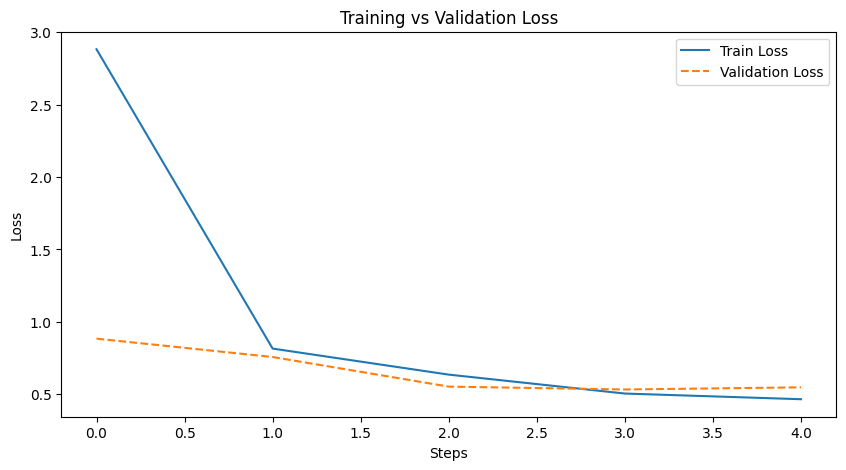

In [ ]:
logs = trainer.state.log_history
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]
steps = range(len(train_loss))
plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss, label="Train Loss")
plt.plot(steps, eval_loss, label="Validation Loss", linestyle="dashed")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
trainer.model.save_pretrained("Sentiment-Adapter")
trainer.processing_class.save_pretrained("Sentiment-Adapter")

('Sentiment-Adapter/tokenizer_config.json',
 'Sentiment-Adapter/special_tokens_map.json',
 'Sentiment-Adapter/tokenizer.json')

In [ ]:
model.load_adapter("Sentiment-Adapter", adapter_name="SeAd")

In [ ]:
model.active_adapters()

['SeAd']

In [ ]:
del peft_model, trainer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
y_after = generate_answers(model, tokenizer, eval_inputs, batch_size=25)

Device set to use cuda:0


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
print(Counter(y_after))
y_after = [1 if y == "POS" else 0 for y in y_after]

Counter({'POS': 140, 'NEG': 110})


In [ ]:
print(classification_report(eval_dataset["label"], y_after))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       107
           1       0.96      0.94      0.95       143

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

